In [1]:
import pandas as pd
from sklearn.metrics import root_mean_squared_error

In [2]:
schema_nav_df = pd.read_parquet('data/clean/schema_nav.parquet')

In [3]:
train_set = schema_nav_df[(schema_nav_df['Date'].dt.year >= 2018) & (schema_nav_df['Date'].dt.year <= 2024)]
test_set = schema_nav_df[schema_nav_df['Date'].dt.year > 2024]


In [4]:
test_set = test_set.copy()
test_set['Naive Forecast'] = (test_set['category_avg_nav'].shift(1).fillna(train_set['category_avg_nav'].iloc[-1]))
rmse = root_mean_squared_error(test_set['category_avg_nav'], 
                            test_set['Naive Forecast'])

print("RMSE: ", rmse)

RMSE:  69.20833150054922


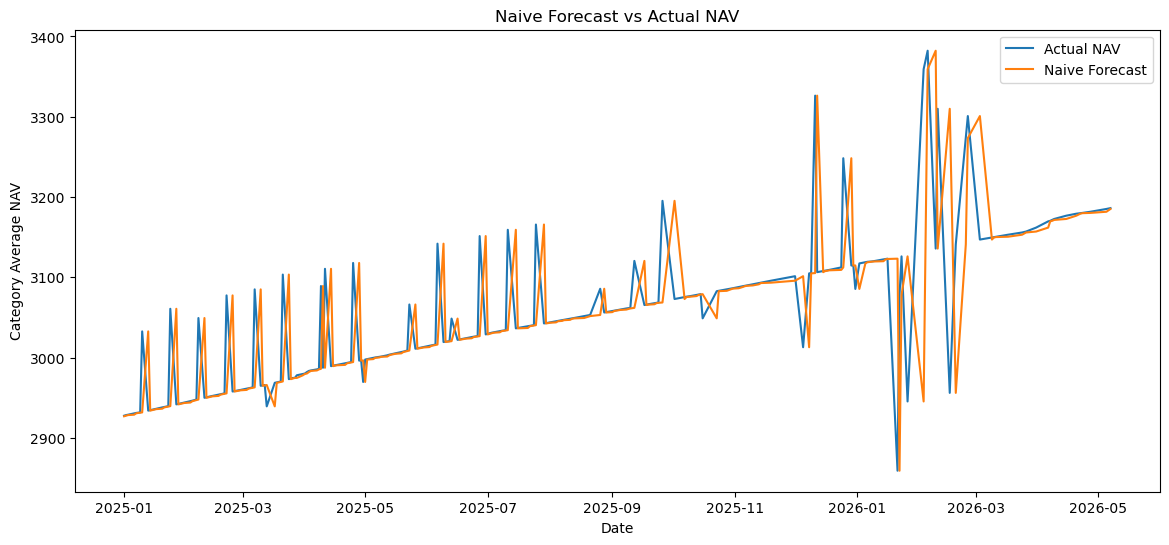

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label='Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['Naive Forecast'],
    label='Naive Forecast'
)

plt.title('Naive Forecast vs Actual NAV')
plt.xlabel('Date')
plt.ylabel('Category Average NAV')

plt.legend()

plt.show()

In [16]:
test_set['moving_average'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=30, min_periods=1)
                                    .mean())

In [17]:
rolling_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average'])

print("Rolling window RMSE: ", rolling_rmse)

Rolling window RMSE:  52.147542785983845


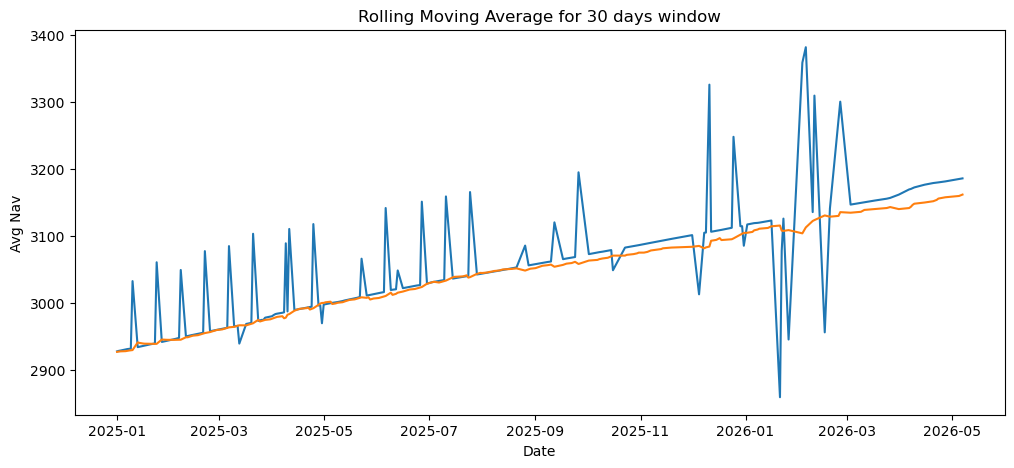

In [18]:
plt.figure(figsize = (12, 5))

plt.plot(
    test_set['Date'],
    test_set['category_avg_nav'],
    label = 'Actual NAV'
)

plt.plot(
    test_set['Date'],
    test_set['moving_average'],
    label = 'Moving Average'
)

plt.title('Rolling Moving Average for 30 days window')
plt.xlabel('Date')
plt.ylabel('Avg Nav')

plt.show()

In [19]:
test_set['moving_average_14'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=14, min_periods=1)
                                    .mean())

rolling_14_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average_14'])

print("Rolling window 14 RMSE: ", rolling_14_rmse)

Rolling window 14 RMSE:  52.10541132225447


In [21]:
test_set['moving_average_7'] = (test_set['category_avg_nav']
                                    .shift(1)
                                    .fillna(train_set['category_avg_nav'].iloc[-1])
                                    .rolling(window=7, min_periods=1)
                                    .mean())

rolling_7_rmse = root_mean_squared_error(test_set['category_avg_nav'], test_set['moving_average_7'])

print("Rolling window 7 RMSE: ", rolling_7_rmse)

Rolling window 7 RMSE:  53.2155552074235


| Model | RMSE | Behavior       |
| ----- | ---- | -------------- |
| Naive | 69.20    | reactive       |
| MA-30 | 52.14    | smooth/lagging |
| MA-14 | 52.10    | smooth/lagging |
| MA-7  | 53.21    | smooth/lagging |